In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from joblib import Parallel, delayed

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet

def triplet(op):                       # the pi+-type member: connected-only, like the old path
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

In [2]:
# sim.distillation.generateDistillFile("./configs/dwf_beta_3.0_m_0.0_Nx_32_Nt_32_N5_16.h5","./configs/dwf_beta_3.0_m_0.0_Nx_32_Nt_32_N5_16.hdf5",
#                                      numVecs=3, autocorrSkip=50,DNums=(0,2))

In [3]:
path = "./configs/dwf_beta_3.0_m_0.0_Nx_32_Nt_32_N5_16.hdf5"
meta = sim.distillation.readDistillMeta(path)

pionBasis = [triplet(MesonOp("g5")),triplet(MesonOp("g5",DNum=2))]
etaBasis = [singlet(MesonOp("g5")),singlet(MesonOp("g5",DNum=2))]

In [4]:
dataPion = sim.GEVP.measureEnsemble(path, meta.configIndices, pionBasis)
dataEta = sim.GEVP.measureEnsemble(path, meta.configIndices, etaBasis)

Measuring configs: 100%|██████████| 100/100 [00:00<00:00, 1188.38it/s]


In [5]:
gevpTi = 2

outPion = sim.GEVP.bootstrapEnsemble(dataPion, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))
outEta = sim.GEVP.bootstrapEnsemble(dataEta, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [6]:
# fitForm="cosh" fits the full periodic single-state shape,
# A e^{-E tau}(1 + e^{-E(T - 2 tau)}) — same two parameters as the exponential,
# but correct through the cosh turnover at T/2, so the window can run to much
# larger t. On Nt = 16 that matters: the exponential needed the window to stop
# by t ~ 5. withAmp=True is still required to overlay the fit in the plots.
fitTpion = [[3, 10],[1,5]]
fitTeta = [[3, 10],[1,5]]

shift = 1

massesPion = sim.GEVP.bootstrapEnsemble(
    dataPion, reduce=sim.GEVP.massReduce(ti=gevpTi, shift=shift, fitT=fitTpion,
                                     withAmp=True, fitForm="sinh"))

massesEta = sim.GEVP.bootstrapEnsemble(
    dataEta, reduce=sim.GEVP.massReduce(ti=gevpTi, shift=shift, fitT=fitTeta,
                                     withAmp=True, fitForm="sinh"))

# the same model for the plots: MUST match massReduce's form/ti/shift
fitModel = sim.plotting.fitCurve("sinh", ti=gevpTi, shift=1, dimt=meta.dimt)

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 16% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 17% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "


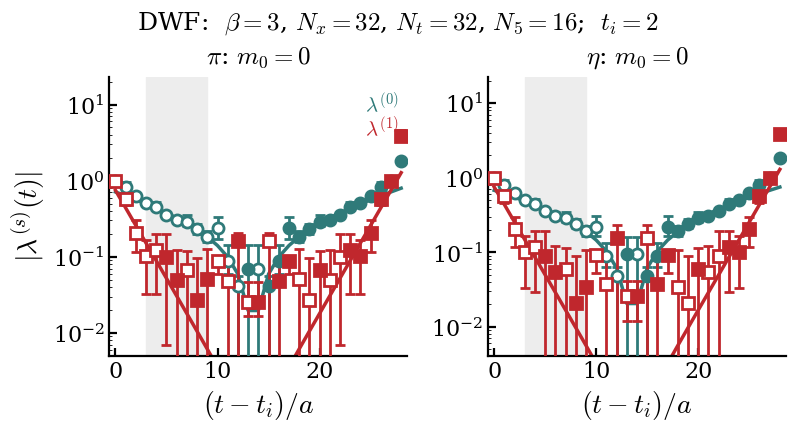

In [7]:
# prinCorrelSemilog takes a LIST of bootstrapEnsemble outputs, one per panel —
# for masses too. A single output is ITSELF [central, err, cov], so passing it
# bare makes the function read 3 "ensembles" and index into the central array.
# fitModel makes the overlaid line the cosh that was actually fitted; without
# it the plot draws a bare exponential that dives below the data past T/2.
sim.plotting.prinCorrelSemilog(
    [outPion, outEta],
    masses=[massesPion, massesEta],
    fitT=[fitTpion,fitTeta],
    fitModel=fitModel,
    labels=[rf"$\pi$: $m_0 = {float(meta.fMass):g}$",rf"$\eta$: $m_0 = {float(meta.fMass):g}$"],
    title=(rf"DWF:  $\beta = {float(meta.beta):g}$, "
           rf"$N_x = {meta.dimx}$, $N_t = {meta.dimt}$, $N_5 = {meta.dim5}$;  "
           rf"$t_i = {gevpTi}$"),
    savePath=f"figs/dwfPrinCorrelSemilog_beta{float(meta.beta):g}"
             f"_m{float(meta.fMass):g}_Nx{meta.dimx}_Nt{meta.dimt}_N5{meta.dim5}.pdf")
plt.show()

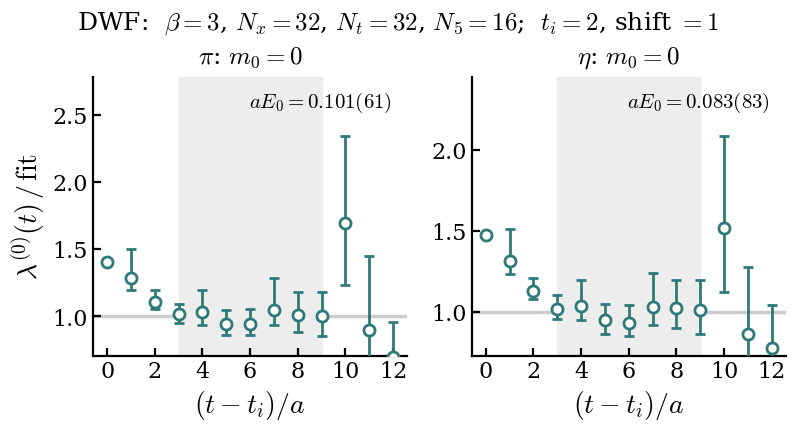

In [8]:
# Ground-state principal correlator divided by its fitted cosh: flat at 1
# wherever the fit describes the data, WITHOUT the upturn past T/2 that the
# exponential ratio showed — the cosh model carries the turnover itself, so
# only genuine deviations (excited states at small t) remain.
sim.plotting.prinCorrelOverFit(
    [outPion, outEta],
    [massesPion, massesEta],
    state=0,
    fitT=[fitTpion,fitTeta],
    fitModel=fitModel,
    tmax=13,
    labels=[rf"$\pi$: $m_0 = {float(meta.fMass):g}$",rf"$\eta$: $m_0 = {float(meta.fMass):g}$"],
    title=(rf"DWF:  "
           rf"$\beta = {float(meta.beta):g}$, $N_x = {meta.dimx}$, "
           rf"$N_t = {meta.dimt}$, $N_5 = {meta.dim5}$;  "
           rf"$t_i = {gevpTi}$, shift $= {shift}$"),
    savePath=f"figs/dwfPrinCorrelOverFit_beta{float(meta.beta):g}"
             f"_m{float(meta.fMass):g}_Nx{meta.dimx}_Nt{meta.dimt}_N5{meta.dim5}.pdf")
plt.show()